### **Configuración Utilizada:**
- Estos son los importes necesarios para la creación del modelo de Regresión Lineal.

In [84]:
# Importación de librerías y funciones necesarias
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

from matplotlib import pyplot as plt

import matplotlib.pyplot as plt
import numpy as np

- Importamos también los ficheros necesarios para la creación de nuestro modelo. Al ser una regresión lineal, en este caso será necesario emplear los datos escalados.

In [85]:
X_train_scaled = pd.read_csv('../Filtrado/X_train_Escalado.csv')
X_test_scaled = pd.read_csv('../Filtrado/X_test_Escalado.csv')

y_train = pd.read_csv('../Filtrado/y_train.csv') 
y_test = pd.read_csv('../Filtrado/y_test.csv') 

### **Mostramos los valores de los diferenetes ficheros para comprobar que sean correctos**

- X_train_scaled

In [86]:
X_train_scaled.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,-2.410476,-1.183003,-0.021304,-0.592818,0.214190,0.641343,-0.467525,0.186563,-0.556779,0.245981,0.429571,1.926107,0.450612,-0.574919,-1.208319
1,-0.006502,0.931313,1.333271,-0.778346,0.861541,0.255988,-1.226356,-0.765946,-0.321177,0.245981,0.276840,-1.257636,0.450612,-0.574919,0.610558
2,1.596148,0.667023,-0.731651,-0.255937,-0.271323,0.388994,-0.315758,-0.765946,0.385632,-0.993546,-1.326837,-1.894385,0.450612,-0.574919,-0.096783
3,0.193829,1.459892,1.219683,2.317050,0.214190,1.194275,0.898372,2.091582,0.974639,-0.993546,-1.250471,0.015861,0.450612,1.734820,1.317898
4,0.594492,-1.381220,-1.450474,0.476412,0.376028,-0.336337,-0.467525,-0.956448,-0.085574,0.245981,-0.181354,-0.620888,-0.503346,-0.574919,-1.107270


- Se muestra como se alberga todos los datos del dataframe

In [87]:
X_train_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16299 entries, 0 to 16298
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       16299 non-null  float64
 1   1       16299 non-null  float64
 2   2       16299 non-null  float64
 3   3       16299 non-null  float64
 4   4       16299 non-null  float64
 5   5       16299 non-null  float64
 6   6       16299 non-null  float64
 7   7       16299 non-null  float64
 8   8       16299 non-null  float64
 9   9       16299 non-null  float64
 10  10      16299 non-null  float64
 11  11      16299 non-null  float64
 12  12      16299 non-null  float64
 13  13      16299 non-null  float64
 14  14      16299 non-null  float64
dtypes: float64(15)
memory usage: 1.9 MB


- X_test_scaled

In [88]:
X_test_scaled.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0.093664,0.204517,0.872139,0.149296,1.104298,-0.834848,1.201904,1.520076,-0.910184,1.485509,0.887764,-1.257636,-0.503346,-0.574919,0.711606
1,-0.206833,0.534879,-1.584406,2.697871,0.699703,-0.515359,-1.226356,-0.765946,0.267830,-0.993546,-0.715913,0.015861,0.450612,1.734820,-1.107270
2,0.594492,-1.050859,0.287247,0.408059,-2.375214,-0.716598,1.201904,-0.765946,0.856837,-0.993546,-0.563181,0.015861,0.450612,-0.574919,-1.107270
3,-0.407164,0.865241,-1.204650,-0.617229,-0.433161,1.339727,-1.226356,1.520076,-0.674581,0.245981,0.735033,1.289358,0.450612,-0.574919,0.610558
4,-0.006502,-1.050859,-0.073860,0.349472,-0.433161,0.743509,0.898372,-0.765946,0.385632,-0.993546,-0.792278,0.015861,0.450612,-0.574919,0.610558


- Se muestra como se alberga todos los datos del dataframe

In [89]:
X_test_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6986 entries, 0 to 6985
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       6986 non-null   float64
 1   1       6986 non-null   float64
 2   2       6986 non-null   float64
 3   3       6986 non-null   float64
 4   4       6986 non-null   float64
 5   5       6986 non-null   float64
 6   6       6986 non-null   float64
 7   7       6986 non-null   float64
 8   8       6986 non-null   float64
 9   9       6986 non-null   float64
 10  10      6986 non-null   float64
 11  11      6986 non-null   float64
 12  12      6986 non-null   float64
 13  13      6986 non-null   float64
 14  14      6986 non-null   float64
dtypes: float64(15)
memory usage: 818.8 KB


- y_train

In [90]:
y_train.head()

,Precio
0,3100.0
1,6000.0
2,4800.0
3,1800.0
4,32700.0


- Se muestra como se alberga todos los datos del dataframe

In [91]:
y_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16299 entries, 0 to 16298
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Precio  16299 non-null  float64
dtypes: float64(1)
memory usage: 127.5 KB


- y_test

In [92]:
y_test.head()

,Precio
0,38500.0
1,13400.0
2,3000.0
3,1900.0
4,3800.0


- Se muestra como se alberga todos los datos del dataframe

In [93]:
y_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6986 entries, 0 to 6985
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Precio  6986 non-null   float64
dtypes: float64(1)
memory usage: 54.7 KB


- Comprobamos cuales es el valor mas bajo de los valores no entrenados

In [94]:
y_test.min()

Precio    1050.0
dtype: float64

- Comprobamos cuales es el valor mas alto de los valores no entrenados

In [95]:
y_test.max()

Precio    167000.0
dtype: float64

### **Entrenamiento Regresión  lineal**

-Una vez que ya tenemos todos los datos, comenzaremos con el entrenamiento de nuestro modelo. En esta ocasión, hemos necesitado el empleo de un logaritmo para su correcto funcionamiento.

In [96]:
modelo = LinearRegression()
y_train_log = np.log1p(y_train)
modelo.fit(X_train_scaled, y_train_log)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [97]:
y_pred_log_test = modelo.predict(X_test_scaled)
y_pred_test = np.expm1(y_pred_log_test)
y_pred_log_train = modelo.predict(X_train_scaled)
y_pred_train = np.expm1(y_pred_log_train)

- Una vez que el modelo ha sido entrenado, compararemos los resultados:

In [98]:
print(f"\n EVALUANDO MODELO:")

# MAE (Error Absoluto Medio) 
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

# RMSE (Raíz del Error Cuadrático Medio) 
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

# R² (coeficiente determinación)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f" ENTRENAMIENTO:")
print(f"   MAE:  ${mae_train:8,.0f} (error promedio)")
print(f"   RMSE: ${rmse_train:8,.0f} (penaliza errores grandes)")
print(f"   R²:   {r2_train:8.3f} ({r2_train*100:.1f}% variabilidad explicada)")

print(f" TEST:")
print(f"   MAE:  ${mae_test:8,.0f} (error promedio)")
print(f"   RMSE: ${rmse_test:8,.0f} (penaliza errores grandes)")
print(f"   R²:   {r2_test:8.3f} ({r2_test*100:.1f}% variabilidad explicada)")


 EVALUANDO MODELO:
 ENTRENAMIENTO:
   MAE:  $   5,652 (error promedio)
   RMSE: $  10,732 (penaliza errores grandes)
   R²:      0.516 (51.6% variabilidad explicada)
 TEST:
   MAE:  $   5,657 (error promedio)
   RMSE: $  10,614 (penaliza errores grandes)
   R²:      0.518 (51.8% variabilidad explicada)


- Vemos que test y train son parecidos lo malo es que falla mucho, es decir el modelo aprende poco

In [99]:
# Diferencias entre train y test
diferencia_mae = abs(mae_test - mae_train)
diferencia_rmse = abs(rmse_test - rmse_train)
diferencia_r2 = abs(r2_test - r2_train)

print(f" DIFERENCIAS:")
print(f"   MAE:  ${diferencia_mae:8,.0f}") 
print(f"   RMSE: ${diferencia_rmse:8,.0f}")


print(f"   R² train/test:   {r2_train:8.3f} / {r2_test:8.3f}")

 DIFERENCIAS:
   MAE:  $       5
   RMSE: $     118
   R² train/test:      0.516 /    0.518


### **Visualizaciones**

- Realizamos un gráfico en el que se muestra el error según el precio real del coche

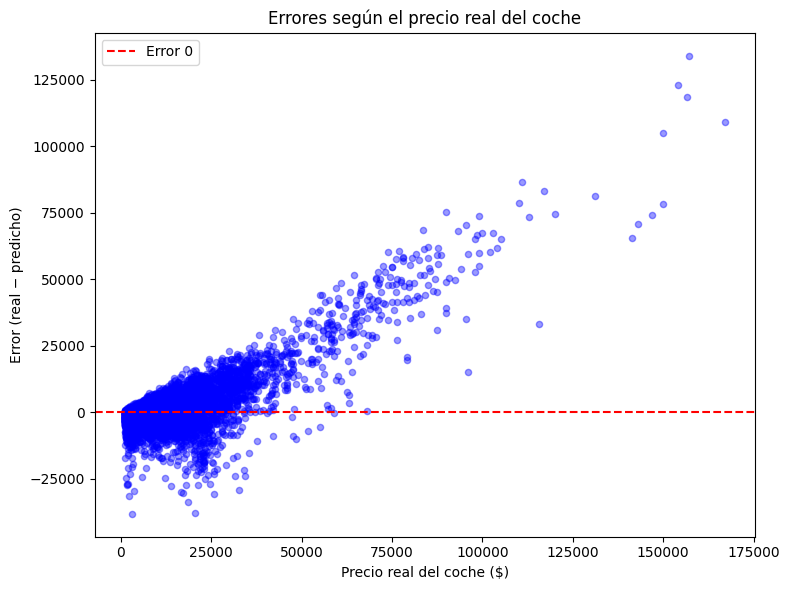

In [100]:
#  Calcula los residuos (errores)
errores = y_test - y_pred_test
precios_reales = y_test

#  Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(precios_reales, errores, alpha=0.4, s=20, color="blue")

# Línea horizontal en 0 (error perfecto)
plt.axhline(0, color="red", linestyle="--", label="Error 0")

# Etiquetas y título
plt.xlabel("Precio real del coche ($)")
plt.ylabel("Error (real − predicho)")
plt.title("Errores según el precio real del coche")
plt.legend()

plt.tight_layout()
plt.show()

- Realizamos un gráfico en el que se muestra la relación entre el valor de la predicción y el valor real del coche.

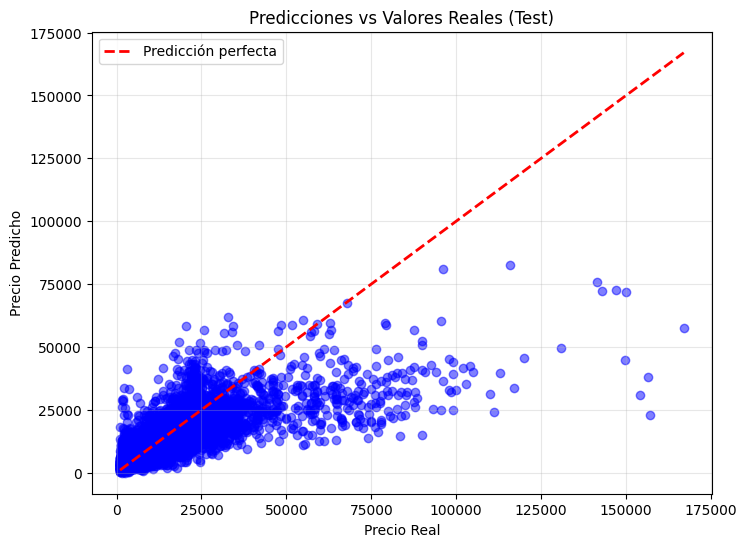

In [101]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()],       # Línea de referencia perfecta, y_test.min() es el valor mínimo de y_test
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Predicción perfecta')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.title('Predicciones vs Valores Reales (Test)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### **Conclusión**
Con esto, nos damos cuenta que este modelo no es el más indicado para este conjunto de datos y que se ve ampliamente superado por el resto de modelos.
